# Member 2 Modeling Notebook: NYC Street Tree Health Predictor

**Role:** Member 2 — Modeling and Evaluation Lead
**Task:** Predict a continuous **tree health score** with **linear regression** (baseline) and a
tuned **Random Forest Regressor** (improved), explain it with **SHAP**, and tune it with
**Weights & Biases** (see `scripts/tune_with_wandb.py`).

**Business problem:** give the city a single number per tree (0 = Poor … 2 = Good) so trees can be
**ranked by inspection priority** (lower score = higher priority). The full, saved artifacts come
from `scripts/create_member2_package.py`; this notebook tells the same story interactively.

## 1. Imports and data loading

In [1]:
%matplotlib inline
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, accuracy_score, confusion_matrix
import shap

RANDOM_STATE = 42
df = pd.read_csv(Path("data/nyc_tree_member1_model_ready_sample.csv"))
print("shape:", df.shape)

shape: (49994, 23)


/sessions/gifted-gracious-curie/.local/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Target: encode health as an ordinal score

We turn the category into a number so we can use **linear regression**: `Poor=0, Fair=1, Good=2`.
A higher score means a healthier tree.

In [2]:
SCORE_MAP = {"Poor": 0, "Fair": 1, "Good": 2}
INV = {v: k for k, v in SCORE_MAP.items()}
CLASS_ORDER = ["Good", "Fair", "Poor"]
df["health_score"] = df["health"].map(SCORE_MAP)

NUMERIC = ["tree_dbh", "problem_count"]
CATEGORICAL = ["species_top15_or_other", "steward", "guards", "sidewalk",
               "has_problem", "boroname", "dbh_group", "curb_loc"]
X = df[NUMERIC + CATEGORICAL]
y = df["health_score"].astype(float)
df["health_score"].value_counts().sort_index()

health_score
0     2812
1     9403
2    37779
Name: count, dtype: int64

## 3. Train/test split and preprocessing

In [3]:
X_train, X_test, y_train, y_test, cat_train, cat_test = train_test_split(
    X, y, df["health"], test_size=0.20, random_state=RANDOM_STATE, stratify=df["health"])
preprocess = ColumnTransformer([
    ("num", StandardScaler(), NUMERIC),
    ("cat", OneHotEncoder(handle_unknown="ignore"), CATEGORICAL),
])

def score_to_cat(a):
    return np.array([INV[i] for i in np.clip(np.rint(a), 0, 2).astype(int)])

def report(name, pred):
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    print(f"{name}: R2={r2_score(y_test, pred):.4f}  RMSE={rmse:.4f}  "
          f"MAE={mean_absolute_error(y_test, pred):.4f}  "
          f"mapped-accuracy={accuracy_score(cat_test, score_to_cat(pred)):.4f}")
print("train:", len(X_train), "test:", len(X_test))

train: 39995 test: 9999


## 4. Baseline — Linear Regression

In [4]:
linreg = Pipeline([("prep", preprocess), ("clf", LinearRegression())])
linreg.fit(X_train, y_train)
lr_pred = linreg.predict(X_test)
report("Linear Regression", lr_pred)

Linear Regression: R2=0.0593  RMSE=0.5509  MAE=0.4247  mapped-accuracy=0.7385


## 5. Improved — Random Forest Regressor with tuning

GridSearchCV over depth and leaf size, scored on R² (3-fold). The search runs on a subsample for
speed; the winner is refit on the full training set.

In [5]:
rf_pipe = Pipeline([("prep", preprocess),
                    ("clf", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1))])
grid = {"clf__max_depth": [10, 16], "clf__min_samples_leaf": [2, 5],
        "clf__n_estimators": [150], "clf__max_features": ["sqrt"]}
X_sub, _, y_sub, _ = train_test_split(X_train, y_train, train_size=8000,
                                      random_state=RANDOM_STATE, stratify=cat_train)
search = GridSearchCV(rf_pipe, grid, scoring="r2",
                      cv=KFold(3, shuffle=True, random_state=RANDOM_STATE),
                      n_jobs=1, refit=False)
search.fit(X_sub, y_sub)
print("best CV R2 (subsample):", round(search.best_score_, 4), search.best_params_)

best = {k.replace("clf__", ""): v for k, v in search.best_params_.items()}
rf = Pipeline([("prep", preprocess),
               ("clf", RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=1, **best))])
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
report("Random Forest Regressor", rf_pred)

best CV R2 (subsample): 0.0716 {'clf__max_depth': 16, 'clf__max_features': 'sqrt', 'clf__min_samples_leaf': 5, 'clf__n_estimators': 150}


Random Forest Regressor: R2=0.0869  RMSE=0.5428  MAE=0.4159  mapped-accuracy=0.7380


## 6. Evaluation — predicted vs actual, residuals, mapped confusion

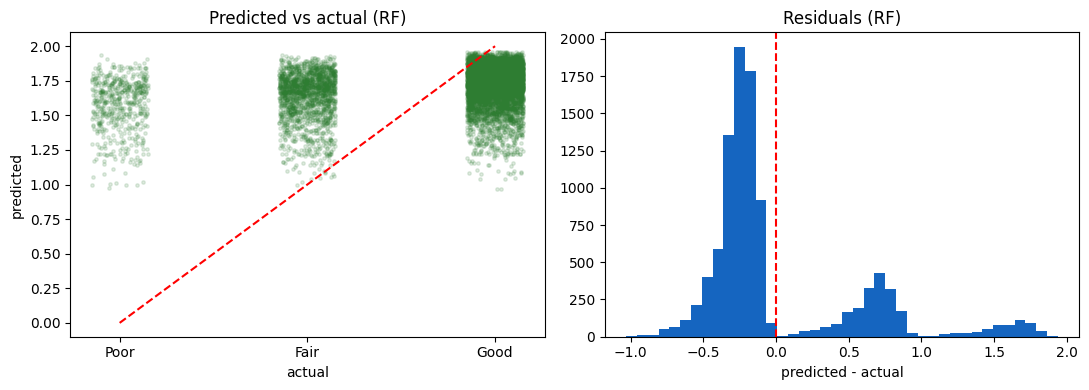

Mapped confusion (rows=actual, cols=pred) ['Good', 'Fair', 'Poor']
      Good  Fair  Poor
Good  7036   520     0
Fair  1538   343     0
Poor   398   164     0


In [6]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
jit = y_test + np.random.default_rng(0).uniform(-0.15, 0.15, len(y_test))
ax[0].scatter(jit, rf_pred, s=6, alpha=0.15, color="#2E7D32")
ax[0].plot([0, 2], [0, 2], "r--"); ax[0].set_xticks([0, 1, 2])
ax[0].set_xticklabels(["Poor", "Fair", "Good"]); ax[0].set_xlabel("actual"); ax[0].set_ylabel("predicted")
ax[0].set_title("Predicted vs actual (RF)")
ax[1].hist(rf_pred - y_test.to_numpy(), bins=40, color="#1565C0"); ax[1].axvline(0, color="r", ls="--")
ax[1].set_title("Residuals (RF)"); ax[1].set_xlabel("predicted - actual")
plt.tight_layout(); plt.show()

cm = confusion_matrix(cat_test, score_to_cat(rf_pred), labels=CLASS_ORDER)
print("Mapped confusion (rows=actual, cols=pred)", CLASS_ORDER)
print(pd.DataFrame(cm, index=CLASS_ORDER, columns=CLASS_ORDER))

**Reading it:** R² is low — tree health is only weakly predictable from these features.
That is an honest finding. The Random Forest still beats the linear baseline and is useful for
*ranking* trees by priority rather than giving a precise health value.

## 7. Explainability — SHAP

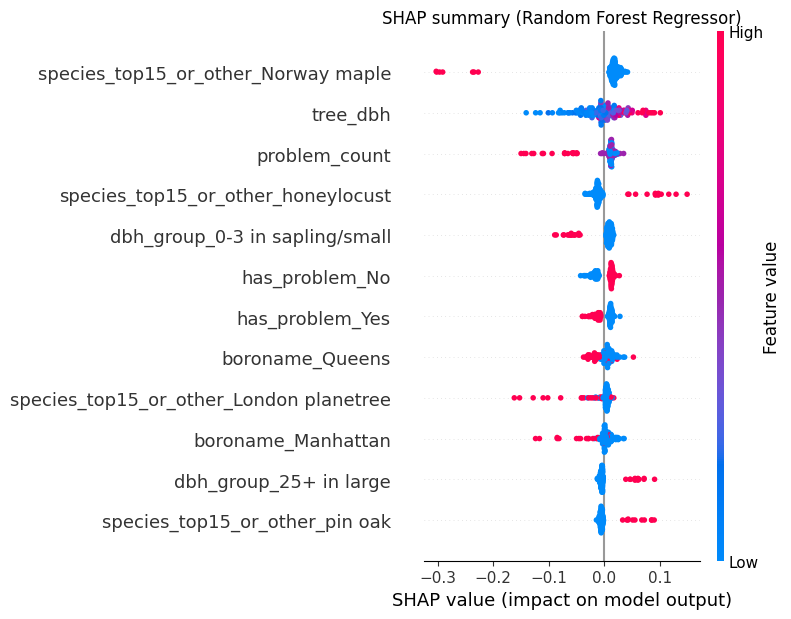

In [7]:
X_s = X_test.iloc[:150]
Xt = rf.named_steps["prep"].transform(X_s)
Xt = Xt.toarray() if hasattr(Xt, "toarray") else np.asarray(Xt)
names = [n.split("__", 1)[1] for n in rf.named_steps["prep"].get_feature_names_out()]
sv = shap.TreeExplainer(rf.named_steps["clf"]).shap_values(Xt, check_additivity=False, approximate=True)
shap.summary_plot(sv, Xt, feature_names=names, max_display=12, show=False)
plt.title("SHAP summary (Random Forest Regressor)"); plt.tight_layout(); plt.show()

**SHAP reading:** red = high feature value. Dots to the right raise the predicted score
(healthier). More visible problems and being a Norway maple push the score down; larger diameter
and species like honeylocust push it up.

## 8. Model comparison and hyperparameter tracking (W&B)

In [8]:
comparison = pd.DataFrame([
    {"model": "Linear Regression (baseline)", "R2": r2_score(y_test, lr_pred),
     "RMSE": np.sqrt(mean_squared_error(y_test, lr_pred))},
    {"model": "Random Forest Regressor (tuned)", "R2": r2_score(y_test, rf_pred),
     "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred))},
]).round(4)
print(comparison.to_string(index=False))

# The full sweep is tracked in Weights & Biases via scripts/tune_with_wandb.py.
wb = Path("data/member2_wandb_runs.csv")
if wb.exists():
    print("\nW&B tracked runs (cv R2):")
    print(pd.read_csv(wb).to_string(index=False))

                          model     R2   RMSE
   Linear Regression (baseline) 0.0593 0.5509
Random Forest Regressor (tuned) 0.0869 0.5428

W&B tracked runs (cv R2):
 max_depth  min_samples_leaf  n_estimators max_features  cv_r2  cv_rmse
        16                 5           150         sqrt 0.0874   0.5433
        16                 2           150         sqrt 0.0847   0.5441
        10                 2           150         sqrt 0.0841   0.5442
        10                 5           150         sqrt 0.0822   0.5448


## 9. Limitations and handoff to Member 3

- **Weak signal / low R²:** report it honestly; frame the app as a triage/ranking tool.
- **Snapshot data (2015):** not live tree health.
- **Association, not causation:** SHAP shows what the model uses, not causes.
- **Handoff:** copy `models/`, `data/member2_*`, and `streamlit_pages/3–5` into the app root.
  Pages load these files directly. Tuning is tracked with W&B; explainability uses SHAP.